# Differentiable ion-beam diagnostics — end-to-end filter optimisation

A differentiable physical model of the filter stack is wired to a CNN and the two
are co-optimised: the per-filter aluminium thicknesses are trained together with
the CNN weights, so the whole chain `thickness → proton image → CNN → beam
parameters` is fit by gradient descent.

1. Load & pre-process the data (splines, images, labels; train/val split)
2. Physical filter model — build it and view a sample image
3. CNN — the parameter regressor, wired to the physical model
4. Training — co-optimise thicknesses and CNN weights
5. Post-training analysis — performance and before/after images

## 1. Load and pre-process the data

Load the differentiable proton splines (the physics lookup tables), the
pre-generated image dataset (padded per-pixel energies, mask and beam-parameter
labels), then normalise the labels and make a train/validation split.

In [99]:
import sys
import os
import dill
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Add the repo root (one directory up) to the path so `src` is importable
sys.path.insert(0, os.path.abspath(".."))

from src.custom.splines.create_proton_splines_torch import (
    TorchCubicSpline1D,
    TorchCubicSpline2D,
)

In [100]:
# Differentiable torch splines: remaining proton energy after the Al filter, and
# energy deposited in the scintillator. These are the physics lookup tables the
# filter model queries.
splines_dir = os.path.join("..", "src", "custom", "splines", "pickles")

al_remaining_spline = TorchCubicSpline2D.load(
    os.path.join(splines_dir, "al_proton_remaining_spline_torch.pt")
)
sc_deposited_spline = TorchCubicSpline1D.load(
    os.path.join(splines_dir, "sc_proton_deposited_spline_torch.pt")
)

In [101]:
# Sanity check: the torch splines should match the original scipy splines they
# were reimplemented from.
with open(os.path.join(splines_dir, "al_proton_remaining_spline.pkl"), "rb") as f:
    al_remaining_scipy = dill.load(f)  # RectBivariateSpline, called as spline(E, thickness)
with open(os.path.join(splines_dir, "sc_proton_deposited_spline.pkl"), "rb") as f:
    sc_deposited_scipy = dill.load(f)  # CubicSpline, called as spline(E)

test_energy = 4.0       # proton energy (MeV)
test_thickness = 1e-3   # Al filter thickness (cm)
print("al_remaining  torch:", float(al_remaining_spline(torch.tensor(test_energy), torch.tensor(test_thickness))),
      "| scipy:", float(al_remaining_scipy(test_energy, test_thickness)[0][0]), "MeV")
print("sc_deposited  torch:", float(sc_deposited_spline(torch.tensor(test_energy))),
      "| scipy:", float(sc_deposited_scipy(test_energy)), "MeV")

al_remaining  torch: 3.8151241680379426 | scipy: 3.815124176972739 MeV
sc_deposited  torch: 0.18130672705663392 | scipy: 0.1813067270566339 MeV


In [102]:
# Pre-generated image dataset: per-pixel padded proton energies, the validity mask
# and the beam-parameter labels (E_max, T_p, N_p).
energies_path = os.path.join("..", "output", "synthetic_images", "custom_energies.pt")
custom_energies = torch.load(energies_path, weights_only=True)

energies_tensor = custom_energies["energies"]  # (N, rows, cols, k)
mask_tensor = custom_energies["mask"]          # (N, rows, cols, k)
energy_labels = custom_energies["labels"]      # (N, 3): E_max, T_p, N_p

print("energies:", tuple(energies_tensor.shape), energies_tensor.dtype)
print("mask:    ", tuple(mask_tensor.shape), mask_tensor.dtype)
print("labels:  ", tuple(energy_labels.shape), energy_labels.dtype)

energies: (5000, 12, 12, 63) torch.float32
mask:     (5000, 12, 12, 63) torch.bool
labels:   (5000, 3) torch.float32


In [103]:
# Per-image particle counts: N_p (real particles) is the third label; the mask
# gives how many macroparticles were simulated per image. n_particles stays raw
# (the physics model uses it to scale image brightness) -- only the regression
# target below is transformed.
n_particles = energy_labels[:, 2]
n_macroparticles = int(mask_tensor.reshape(mask_tensor.shape[0], -1).sum(dim=1)[0])

# Regression targets: log10 the particle count (N_p, index 2) before min-max
# scaling, matching the real pipeline (src/custom_op.py) -- N_p spans orders of
# magnitude, while E_max and T_p are left linear. All three then map to [0, 1].
scaled_labels = energy_labels.clone()
scaled_labels[:, 2] = torch.log10(scaled_labels[:, 2])
label_min = scaled_labels.min(dim=0).values
label_max = scaled_labels.max(dim=0).values
labels_norm = (scaled_labels - label_min) / (label_max - label_min)

# Reproducible train/validation split.
torch.manual_seed(0)
n_val = 20
perm = torch.randperm(energies_tensor.shape[0])
val_idx, train_idx = perm[:n_val], perm[n_val:]
print(f"train: {len(train_idx)} samples | val: {len(val_idx)} samples")

train: 4980 samples | val: 20 samples


## 2. Physical filter model

A differentiable model of the detector: an integer mesh assigns each pixel a
filter, each filter has its own learnable aluminium thickness, and padded proton
energies are pushed through the aluminium spline (at the pixel's thickness) then
the scintillator spline. Particle-number scaling, a Gaussian blur and a fixed
calibration to camera counts complete the forward model. The only learnable
parameters are the per-filter thicknesses.

In [104]:
class FilterStackLayer(nn.Module):
    """Optimisable aluminium-filter stack over an integer mesh of filter IDs.

    filter_mesh: (rows, cols) integer array; each distinct value is a filter with
        its own learnable thickness. init_thicknesses (cm) are indexed by the
        sorted unique IDs. Thicknesses are kept within [thickness_min, thickness_max]
        via a scaled sigmoid.
    forward(energies, mask): energies of shape (..., rows, cols, k) padded per
        pixel; returns the summed deposited energy of shape (..., rows, cols).
    """

    def __init__(
        self, filter_mesh, init_thicknesses, al_spline, sc_spline,
        thickness_min=None, thickness_max=None,
    ):
        super().__init__()
        self.al_spline = al_spline
        self.sc_spline = sc_spline
        dtype = al_spline.x.dtype

        mesh = torch.as_tensor(filter_mesh, dtype=torch.long)
        unique_ids = torch.unique(mesh)  # sorted
        index_mesh = torch.searchsorted(unique_ids, mesh.reshape(-1)).reshape(mesh.shape)
        self.register_buffer("index_mesh", index_mesh)  # (rows, cols) in [0, n_filters)

        # Bound thicknesses to the spline domain by default (both ends enforced).
        self.thickness_min = float(al_spline.y[0]) if thickness_min is None else float(thickness_min)
        self.thickness_max = float(al_spline.y[-1]) if thickness_max is None else float(thickness_max)
        span = self.thickness_max - self.thickness_min

        init_t = torch.as_tensor(init_thicknesses, dtype=dtype)
        p = ((init_t - self.thickness_min) / span).clamp(1e-6, 1 - 1e-6)
        raw0 = torch.log(p / (1 - p))  # inverse sigmoid (logit)
        self.raw_thickness = nn.Parameter(raw0)

    @property
    def thickness(self):
        """Per-filter thickness in cm, in (thickness_min, thickness_max)."""
        span = self.thickness_max - self.thickness_min
        return self.thickness_min + span * torch.sigmoid(self.raw_thickness)

    def forward(self, energies, mask=None):
        thickness_grid = self.thickness[self.index_mesh].unsqueeze(-1)  # (rows, cols, 1)
        remaining = self.al_spline(energies, thickness_grid)            # broadcasts over batch and k
        deposited = self.sc_spline(remaining)
        if mask is not None:
            deposited = deposited * mask.to(deposited.dtype)
        return deposited.sum(dim=-1)  # (..., rows, cols)

class GaussianSmoothLayer(nn.Module):
    """Fixed-kernel Gaussian blur (approximates smooth_squares' scintillator response).

    Single global blur with a registered (non-learnable) kernel; reflect padding
    matches scipy's gaussian_filter default. Differentiable.
    """

    def __init__(self, sigma=1.0, truncate=4.0):
        super().__init__()
        radius = max(1, int(truncate * sigma + 0.5))
        coords = torch.arange(-radius, radius + 1, dtype=torch.float64)
        k1d = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        k1d = k1d / k1d.sum()
        self.register_buffer("kernel", torch.outer(k1d, k1d)[None, None])  # (1,1,K,K)
        self.radius = radius

    def forward(self, image):  # image: (N, H, W)
        x = F.pad(image.unsqueeze(1), (self.radius,) * 4, mode="reflect")
        return F.conv2d(x, self.kernel.to(x.dtype)).squeeze(1)


class CalibrationLayer(nn.Module):
    """Scale to camera counts against a fixed reference; round only in eval().

    `scale` is a fixed brightness that maps to `max_count`. In train() the output
    is the smooth unrounded scaling (differentiable, unbounded); in eval() it is
    clamped to [0, max_count] and rounded to integer counts (the physical detector).
    """

    def __init__(self, scale, max_count=4095):
        super().__init__()
        self.register_buffer("scale", torch.as_tensor(float(scale), dtype=torch.float64))
        self.max_count = max_count

    def forward(self, image):
        counts = image / self.scale * self.max_count
        if self.training:
            return counts
        return counts.clamp(0, self.max_count).round()

class ProtonImageModel(nn.Module):
    """End-to-end differentiable proton image: padded energies -> camera counts.

    The only learnable parameters are the per-filter thicknesses (inside
    filter_stack). n_particles (N_p) is supplied per sample from the label.
    """

    def __init__(
        self, filter_mesh, init_thicknesses, al_spline, sc_spline,
        n_macroparticles, calibration_scale, sigma=1.0,
        thickness_min=None, thickness_max=None,
    ):
        super().__init__()
        self.filter_stack = FilterStackLayer(
            filter_mesh, init_thicknesses, al_spline, sc_spline, thickness_min, thickness_max
        )
        self.smooth = GaussianSmoothLayer(sigma)
        self.calibrate = CalibrationLayer(calibration_scale)
        self.n_macroparticles = float(n_macroparticles)

    def forward(self, energies, mask, n_particles):
        grid = self.filter_stack(energies, mask)                       # (N, H, W)
        scale = (n_particles.to(grid.dtype) / self.n_macroparticles).reshape(-1, 1, 1)
        grid = grid * scale                                            # particle-number scaling
        grid = self.smooth(grid)
        return self.calibrate(grid)

    @property
    def thickness(self):
        return self.filter_stack.thickness

In [105]:
# 12x12 pixel mesh: a 3x3 grid of filters (ids 1..9), each a 4x4 block of pixels.
# Each distinct id is a filter with its own learnable thickness; the mesh shape
# also sets the image size (and hence the CNN input width).
filter_mesh = np.kron(np.arange(1, 10).reshape(3, 3), np.ones((4, 4), dtype=int))
print(filter_mesh)

[[1 1 1 1 2 2 2 2 3 3 3 3]
 [1 1 1 1 2 2 2 2 3 3 3 3]
 [1 1 1 1 2 2 2 2 3 3 3 3]
 [1 1 1 1 2 2 2 2 3 3 3 3]
 [4 4 4 4 5 5 5 5 6 6 6 6]
 [4 4 4 4 5 5 5 5 6 6 6 6]
 [4 4 4 4 5 5 5 5 6 6 6 6]
 [4 4 4 4 5 5 5 5 6 6 6 6]
 [7 7 7 7 8 8 8 8 9 9 9 9]
 [7 7 7 7 8 8 8 8 9 9 9 9]
 [7 7 7 7 8 8 8 8 9 9 9 9]
 [7 7 7 7 8 8 8 8 9 9 9 9]]


## 3. Initialise the CNN

The CNN regresses the beam parameters (E_max, T_p, N_p) from the image. Stacking
it on the physical model closes the loop — `thickness → image → CNN →
prediction` — so one backward pass can reach both the CNN weights and the filter
thicknesses.

In [106]:
class Net(nn.Module):
    """CNN mapping a (image_width x image_width) image to the beam parameters.

    Copied from machine_learning/pytorch_trial.py; the original `x = torch.tensor(x)`
    at the top of forward was removed because it detaches the autograd graph (which
    would sever gradients coming from ProtonImageModel).
    """

    def __init__(self, image_width, n_outputs):
        super().__init__()
        self.image_width = image_width
        width_after_conv = (((image_width - 2) // 2) - 2) // 2

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * width_after_conv ** 2, 64)
        self.fc2 = nn.Linear(64, n_outputs)

    def forward(self, x):
        x = x.view(-1, 1, self.image_width, self.image_width)  # keeps the graph intact

        x = torch.relu(self.conv1(x))
        x = self.pool1(x)
        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## 4. Training

Two runs from the same starting point — all filters uniform at 50 um, with
identical CNN initialisation and the same train/val split — so the only
difference is whether the thicknesses are optimised:

- **Step 1 — fixed filter:** thicknesses frozen at the uniform 50 um init; only
  the CNN trains (`train_thickness=False`).
- **Step 2 — learned filter:** the same uniform 50 um init, but the thicknesses
  are co-optimised with the CNN.

`train` co-optimises the CNN weights and (optionally) the filter thicknesses,
minibatched because a full-batch backward through the ~5M-query spline graph runs
out of memory; the thickness (raw, sigmoid-space) uses a larger LR than the CNN.

In [123]:
def predict(model, cnn, idx):
    """Physics image -> normalised CNN input -> CNN prediction (graph intact)."""
    img = model(energies_tensor[idx], mask_tensor[idx], n_particles[idx])
    return cnn((img / model.calibrate.max_count).float())


def train(model, cnn, train_idx, val_idx, epochs=20, batch_size=16,
          cnn_lr=1e-3, thickness_lr=1e-2, train_thickness=True, verbose=True):
    """Co-optimise the CNN weights and (optionally) the filter thicknesses.

    Trains both modules in place and returns a history dict of train/val MSE (on the
    normalised labels). history[*][0] is the pre-training baseline (epoch 0, before
    any update); entries 1..epochs are the trained epochs. Set train_thickness=False
    to freeze the thicknesses and train the CNN only (the fixed-filter baseline). The
    thickness (raw, sigmoid-space) uses a larger LR than the CNN weights.
    """
    param_groups = [{"params": cnn.parameters(), "lr": cnn_lr}]
    if train_thickness:
        param_groups.append({"params": model.parameters(), "lr": thickness_lr})  # only raw_thickness
    optimizer = torch.optim.Adam(param_groups)

    def mean_loss(idx_set):
        """Mean MSE over an index set, in minibatches under no_grad (no updates)."""
        total = 0.0
        with torch.no_grad():
            for b in range(0, len(idx_set), batch_size):
                idx = idx_set[b:b + batch_size]
                total += float(F.mse_loss(predict(model, cnn, idx), labels_norm[idx].float())) * len(idx)
        return total / len(idx_set)

    history = {"train": [], "val": []}

    def record(epoch, train_loss, val_loss, note=""):
        history["train"].append(train_loss)
        history["val"].append(val_loss)
        if verbose:
            print(f"epoch {epoch:2d} {note:9s}| train {train_loss:.4f} | val {val_loss:.4f}")

    # Epoch 0: the untrained baseline, before any gradient step.
    model.train()
    cnn.train()
    record(0, mean_loss(train_idx), mean_loss(val_idx), "(before)")

    for epoch in range(1, epochs + 1):
        model.train()
        cnn.train()
        running = 0.0
        for b in range(0, len(train_idx), batch_size):
            idx = train_idx[b:b + batch_size]
            optimizer.zero_grad()
            loss = F.mse_loss(predict(model, cnn, idx), labels_norm[idx].float())
            loss.backward()
            optimizer.step()
            running += float(loss) * len(idx)

        with torch.no_grad():  # validation: forward only, so no spline graph is stored
            val_loss = float(F.mse_loss(predict(model, cnn, val_idx), labels_norm[val_idx].float()))
        record(epoch, running / len(train_idx), val_loss)
    return history

In [124]:
# Fresh model + fresh CNN for each run; same split and epochs for a fair compare.
COMPARE_EPOCHS = 20

def build_model(thicknesses_cm):
    """A ProtonImageModel at the given thicknesses, with its own frozen calibration
    (peak brightness of that config over a 500-sample subset -> max_count)."""
    with torch.no_grad():
        stack = FilterStackLayer(filter_mesh, thicknesses_cm, al_remaining_spline, sc_deposited_spline)
        samp = torch.randperm(energies_tensor.shape[0])[:500]
        g = stack(energies_tensor[samp], mask_tensor[samp]) * (n_particles[samp].double() / n_macroparticles).reshape(-1, 1, 1)
        scale = float(GaussianSmoothLayer(sigma=1.0)(g).max())
    return ProtonImageModel(
        filter_mesh, thicknesses_cm, al_remaining_spline, sc_deposited_spline,
        n_macroparticles=n_macroparticles, calibration_scale=scale, sigma=1.0,
    )

# --- Step 1: fixed uniform filter, train the CNN only (baseline) ---
uniform_thicknesses_cm = [50e-4] * len(np.unique(filter_mesh))
model_fixed = build_model(uniform_thicknesses_cm)
torch.manual_seed(0)  # identical CNN init for both runs, so only thickness-optimisation differs
cnn_fixed = Net(image_width=filter_mesh.shape[0], n_outputs=energy_labels.shape[1])
print("=== Step 1: fixed uniform 50 um filter, CNN only ===")
hist_fixed = train(model_fixed, cnn_fixed, train_idx, val_idx, epochs=COMPARE_EPOCHS, train_thickness=False)

=== Step 1: fixed uniform 50 um filter, CNN only ===
epoch  0 (before) | train 0.4522 | val 0.4209
epoch  1          | train 0.0660 | val 0.0402
epoch  2          | train 0.0446 | val 0.0359
epoch  3          | train 0.0434 | val 0.0347
epoch  4          | train 0.0428 | val 0.0342
epoch  5          | train 0.0423 | val 0.0338
epoch  6          | train 0.0420 | val 0.0337
epoch  7          | train 0.0418 | val 0.0334
epoch  8          | train 0.0416 | val 0.0332
epoch  9          | train 0.0414 | val 0.0331
epoch 10          | train 0.0413 | val 0.0333
epoch 11          | train 0.0411 | val 0.0329
epoch 12          | train 0.0410 | val 0.0330
epoch 13          | train 0.0409 | val 0.0331
epoch 14          | train 0.0408 | val 0.0328
epoch 15          | train 0.0407 | val 0.0325
epoch 16          | train 0.0405 | val 0.0326
epoch 17          | train 0.0405 | val 0.0325
epoch 18          | train 0.0403 | val 0.0327
epoch 19          | train 0.0401 | val 0.0328
epoch 20          | train 0

In [125]:
# --- Step 2: init all filters at 50 um, co-optimise filter + CNN ---
uniform_thicknesses_cm = [50e-4] * len(np.unique(filter_mesh))
model_joint = build_model(uniform_thicknesses_cm)
torch.manual_seed(0)  # same CNN init as Step 1
cnn_joint = Net(image_width=filter_mesh.shape[0], n_outputs=energy_labels.shape[1])
print("=== Step 2: init 50 um, co-optimised (filter + CNN) ===")
hist_joint = train(model_joint, cnn_joint, train_idx, val_idx, epochs=COMPARE_EPOCHS, train_thickness=True)

print("\nfilter thicknesses after co-optimisation (um):",
      [round(float(t) * 1e4, 2) for t in model_joint.thickness])

=== Step 2: init 50 um, co-optimised (filter + CNN) ===
epoch  0 (before) | train 0.4522 | val 0.4209
epoch  1          | train 0.0648 | val 0.0332
epoch  2          | train 0.0390 | val 0.0296
epoch  3          | train 0.0337 | val 0.0281
epoch  4          | train 0.0293 | val 0.0264
epoch  5          | train 0.0266 | val 0.0214
epoch  6          | train 0.0248 | val 0.0195
epoch  7          | train 0.0233 | val 0.0190
epoch  8          | train 0.0223 | val 0.0176
epoch  9          | train 0.0215 | val 0.0157
epoch 10          | train 0.0208 | val 0.0151
epoch 11          | train 0.0203 | val 0.0143
epoch 12          | train 0.0198 | val 0.0140
epoch 13          | train 0.0194 | val 0.0136
epoch 14          | train 0.0189 | val 0.0132
epoch 15          | train 0.0185 | val 0.0125
epoch 16          | train 0.0181 | val 0.0125
epoch 17          | train 0.0178 | val 0.0123
epoch 18          | train 0.0175 | val 0.0122
epoch 19          | train 0.0173 | val 0.0119
epoch 20          | trai

## 5. Post-training analysis

Compare the two runs: does co-optimising the thicknesses (from the uniform 50 um
start) beat leaving them fixed? Then visualise what the learned filter does to a
sample image (before vs after).

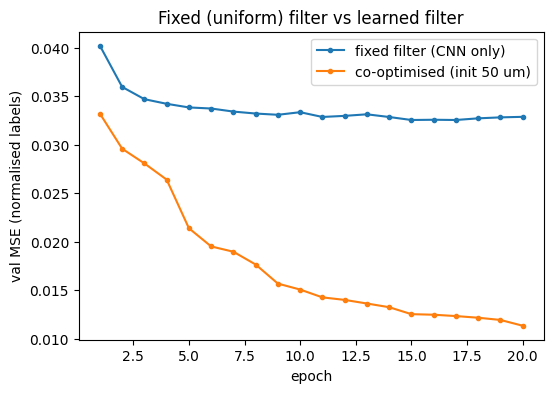

final val MSE | fixed: 0.03286 | co-optimised: 0.01134
target     fixed    co-opt
E_max    0.02110   0.01059
T_p      0.06705   0.02239
N_p      0.01044   0.00103


In [128]:
# Validation curves and final per-target error for both runs (Section 4).
fig, ax = plt.subplots(figsize=(6, 4))
# Skip epoch 0 (the pre-training baseline) so the trained epochs aren't dwarfed by it.
epochs_axis = range(1, len(hist_fixed["val"]))
ax.plot(epochs_axis, hist_fixed["val"][1:], marker=".", label="fixed filter (CNN only)")
ax.plot(epochs_axis, hist_joint["val"][1:], marker=".", label="co-optimised (init 50 um)")
ax.set_xlabel("epoch")
ax.set_ylabel("val MSE (normalised labels)")
ax.set_title("Fixed (uniform) filter vs learned filter")
ax.legend()
plt.show()

def per_target_val(model, cnn):
    model.train(); cnn.train()  # match the training loop's val computation (no rounding)
    with torch.no_grad():
        p = predict(model, cnn, val_idx)
        t = labels_norm[val_idx].float()
    return float(F.mse_loss(p, t)), ((p - t) ** 2).mean(dim=0)

mse_fixed, tgt_fixed = per_target_val(model_fixed, cnn_fixed)
mse_joint, tgt_joint = per_target_val(model_joint, cnn_joint)
print(f"final val MSE | fixed: {mse_fixed:.5f} | co-optimised: {mse_joint:.5f}")
print(f"{"target":6s} {"fixed":>9s} {"co-opt":>9s}")
for name, a, b in zip(["E_max", "T_p", "N_p"], tgt_fixed, tgt_joint):
    print(f"{name:6s} {float(a):9.5f} {float(b):9.5f}")

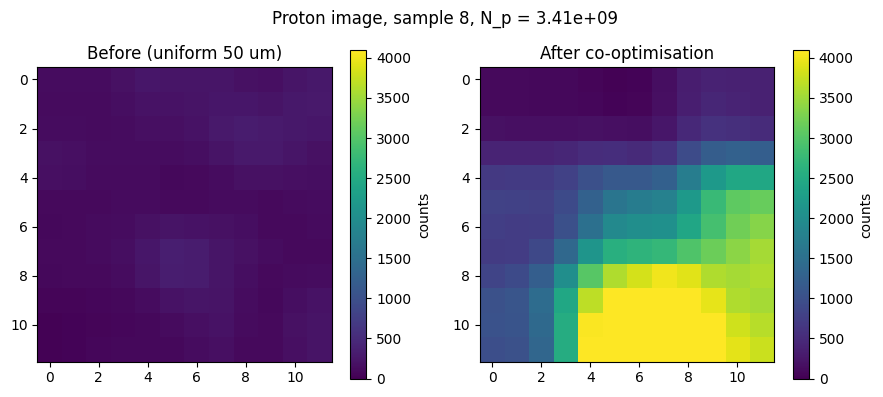

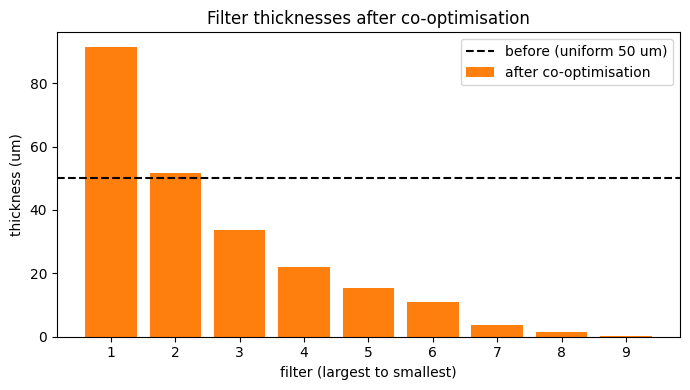

In [137]:
# The co-optimised filter's effect on a sample image: before (uniform 50 um init)
# vs after training. Eval mode = the physical detector (counts clamped and rounded).
sample = 8
sl = slice(sample, sample + 1)

# "Before" reuses model_joint's own calibration so the two panels are comparable.
before_model = ProtonImageModel(
    filter_mesh, uniform_thicknesses_cm, al_remaining_spline, sc_deposited_spline,
    n_macroparticles=n_macroparticles, calibration_scale=float(model_joint.calibrate.scale), sigma=1.0,
)
before_model.eval()
model_joint.eval()
with torch.no_grad():
    before_img = before_model(energies_tensor[sl], mask_tensor[sl], n_particles[sl])[0]
    after_img = model_joint(energies_tensor[sl], mask_tensor[sl], n_particles[sl])[0]

vmax = float(max(before_img.max(), after_img.max()))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, img, title in zip(axes, [before_img, after_img], ["Before (uniform 50 um)", "After co-optimisation"]):
    im = ax.imshow(img, cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="counts")
fig.suptitle(f"Proton image, sample {sample}, N_p = {float(n_particles[sample]):.2e}")
plt.tight_layout()
plt.show()

# Per-filter thickness after co-optimisation, sorted largest to smallest, with a
# horizontal line for the uniform 50 um starting point (the "before").
before_um = uniform_thicknesses_cm[0] * 1e4  # all filters start equal
after_sorted = np.sort([float(t) * 1e4 for t in model_joint.thickness])[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(1, len(after_sorted) + 1)
ax.bar(x, after_sorted, color="C1", label="after co-optimisation")
ax.axhline(before_um, color="k", linestyle="--", label=f"before (uniform {before_um:.0f} um)")
ax.set_xticks(x)
ax.set_xlabel("filter (largest to smallest)")
ax.set_ylabel("thickness (um)")
ax.set_title("Filter thicknesses after co-optimisation")
ax.legend()
plt.tight_layout()
plt.show()